In [31]:
#CH.SC.U4CSE24015 - Deepak Bharathwaj S

In [32]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

import seaborn as sn
import matplotlib.pyplot as plt

from sklearn import tree

In [33]:
data = pd.read_csv("fruit_random_forest_dataset.csv")

In [34]:
display(data.head())

,fruit_id,weight_g,diameter_cm,length_cm,width_cm,red_value,green_value,yellow_value,sweetness_score,firmness_score,seed_count,shape_code,fruit
0,1,140.34,3.38,18.40,3.46,190.25,192.52,192.88,7.36,6.80,0,1,Banana
1,2,175.08,6.87,7.29,5.85,186.94,133.92,110.67,4.86,5.16,32,0,Guava
2,3,95.90,4.50,7.43,5.01,215.13,186.55,205.75,2.23,7.51,7,2,Lemon
3,4,223.22,8.11,7.31,8.01,185.30,89.06,35.32,7.40,8.05,5,0,Apple
4,5,84.85,2.61,17.91,3.30,213.06,163.45,233.29,8.75,5.98,0,1,Banana


In [35]:
x = data.iloc[:, 1:-1].values
y = data.iloc[:, -1].values

print(x.shape)
print(y.shape)

(600, 11)
(600,)


In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=41)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 420
Testing samples: 180


In [37]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [38]:
model = RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [39]:
print('Random Forest Classifier')

conf_mat = metrics.confusion_matrix(y_test, y_pred)

print('\nConfusion Matrix :\n', conf_mat)

Accuracy_score = accuracy_score(y_test, y_pred)

print('Accuracy Score : ', Accuracy_score)

print('Accuracy in Percentage : ',
      int(Accuracy_score * 100), '%')

print('\n', classification_report(y_test, y_pred))

Random Forest Classifier

Confusion Matrix :
 [[39  0  0  0  0  0]
 [ 0 27  0  0  0  0]
 [ 0  0 24  0  0  0]
 [ 0  0  0 32  0  0]
 [ 0  0  0  0 28  0]
 [ 0  0  0  0  0 30]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %

               precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        39
      Banana       1.00      1.00      1.00        27
       Guava       1.00      1.00      1.00        24
       Lemon       1.00      1.00      1.00        32
       Mango       1.00      1.00      1.00        28
      Orange       1.00      1.00      1.00        30

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



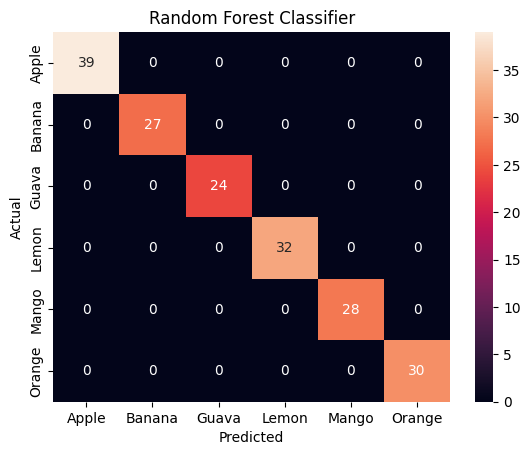

In [40]:
conf_mat = pd.crosstab(y_test,y_pred,rownames=['Actual'],colnames=['Predicted'])

sn.heatmap(conf_mat, annot=True, fmt='d')

plt.title('Random Forest Classifier')
plt.show()

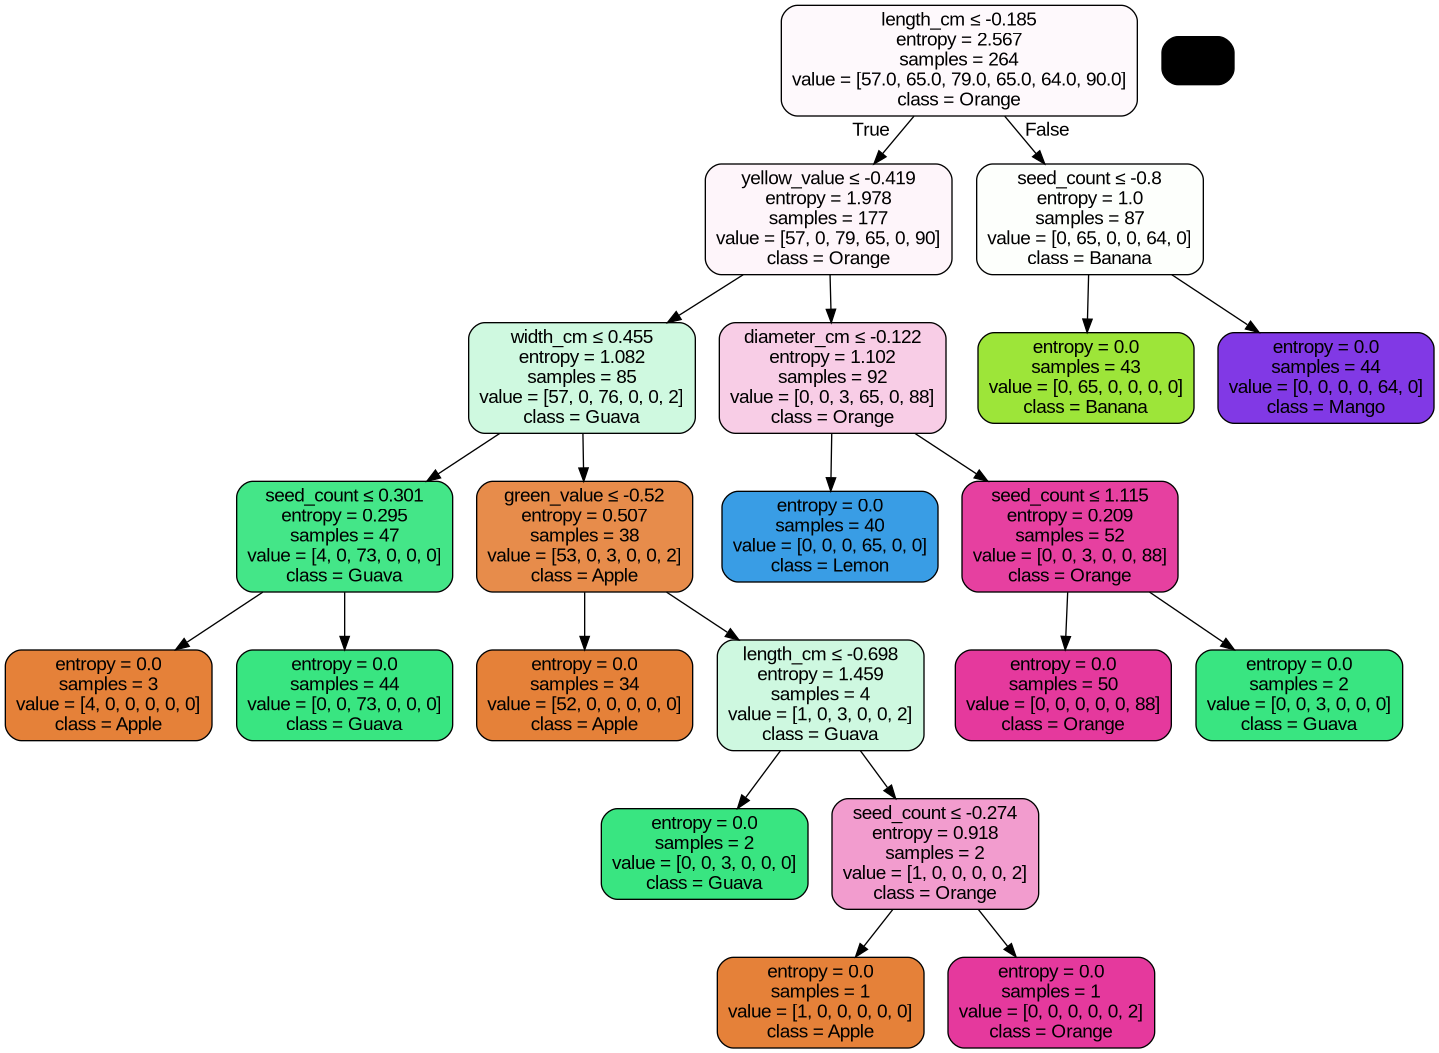

In [41]:
import pydotplus
from IPython.display import Image

dot_data = tree.export_graphviz(model.estimators_[0],out_file=None,feature_names=data.columns[1:-1],class_names=model.classes_,filled=True,rounded=True,special_characters=True)

graph = pydotplus.graph_from_dot_data(dot_data)

Image(graph.create_png())